# Week 12 - Exercise
### Notebook created by Jonathan Penava

In this exercise you are going to build a Tensor Flow model similar to the numbers example, but this time it will try to predict an article of clothing.  fashion_mnist is a similar dataset to what you saw in class, but with clothing.  I have started you with some code.

In [1]:
import tensorflow as ts
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt


In [2]:
import tensorflow.keras as tk
fashion_mnist = tk.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
labels=['T-shirt/Top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


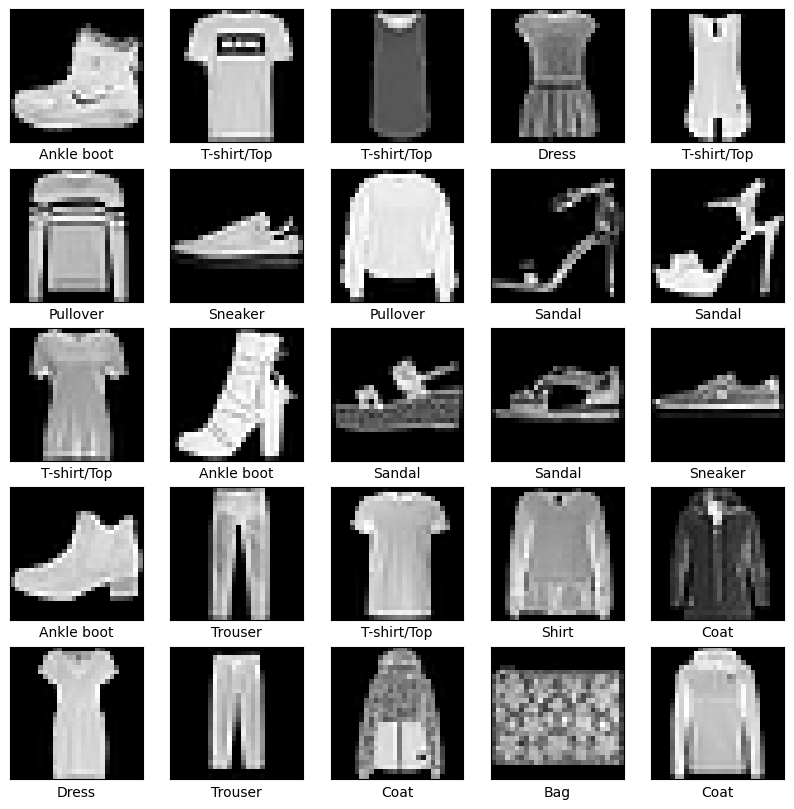

In [3]:
plt.figure(figsize=(10,10))
for i in range(25): 
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(train_images[i],cmap='grey')
  plt.xlabel(labels[train_labels[i]])
plt.show()

Complete the model based on what we did in class.  Then, find yourself an image online, and try to have your model predict what it is.  If your model does not predict your image, examine the probability of all the outcomes to see if your model was close.

<span style="color:red;">At the end your model will have picked a number.  To get the name of the clothing item to appear you can use that number as the index in the labels list<br><br>
print(labels[num])
</span>

In [3]:
from keras.models import Sequential
from keras.layers import Dense,Conv2D,Flatten

#The reshape identifies (# of images, and our input shape)
x_train=train_images.reshape(60000,28,28,1)
x_test=test_images.reshape(10000,28,28,1)

model=Sequential()
#We add a series of convolution layers to our model.  
# (Number of filters, kernel size (The size of the area being analyzed(width, height)), activation layer of our node, input_shape)
#Convolution is commonly used in bluring or sharpening images.
#It is an image processing function.  It examines clusters of pixels, contrasting adjacent pixels.  
model.add(Conv2D(128,(2,2),activation='relu',input_shape=(28,28,1)))
model.add(Conv2D(64,(2,2),activation='relu',input_shape=(28,28,1)))
model.add(Conv2D(32,(2,2),activation='relu',input_shape=(28,28,1)))
model.add(Conv2D(16,(2,2),activation='relu',input_shape=(28,28,1)))
#Convert output of previous layers into a 1D representation.
model.add(Flatten())
#The dense layer builds our nerual network where it connects each node of our prevous layers to the node.
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
#The last layer of our dense layer will be our possible outputs.  Since we have 10 possibilities we will have 10 here.
model.add(Dense(10,activation='softmax'))
#Optimizer - we have a choice of a few to use here https://keras.io/api/optimizers/
#Loss - https://keras.io/api/losses/
model.compile(optimizer='Adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

c:\Users\hp\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
model.fit(x_train,train_labels,epochs=5,validation_split=0.1)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 109s 62ms/step - accuracy: 0.8525 - loss: 0.4218 - val_accuracy: 0.8768 - val_loss: 0.3310
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 83s 49ms/step - accuracy: 0.9040 - loss: 0.2645 - val_accuracy: 0.8928 - val_loss: 0.3090
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 81s 48ms/step - accuracy: 0.9247 - loss: 0.2020 - val_accuracy: 0.9027 - val_loss: 0.2716
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 83s 49ms/step - accuracy: 0.9452 - loss: 0.1519 - val_accuracy: 0.9025 - val_loss: 0.3037
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 87s 52ms/step - accuracy: 0.9584 - loss: 0.1154 - val_accuracy: 0.9038 - val_loss: 0.3085


In [10]:
from sklearn.metrics import classification_report
predictions = model.predict(x_test)
print(classification_report(test_labels,predictions.argmax(axis=1)))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
              precision    recall  f1-score   support

           0       0.87      0.82      0.85      1000
           1       0.99      0.97      0.98      1000
           2       0.89      0.77      0.83      1000
           3       0.90      0.90      0.90      1000
           4       0.80      0.87      0.83      1000
           5       0.98      0.97      0.97      1000
           6       0.69      0.79      0.73      1000
           7       0.94      0.98      0.96      1000
           8       0.98      0.97      0.98      1000
           9       0.97      0.94      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [13]:
import cv2
file = r'tshirt.png'
testing = cv2.imread(file, cv2.IMREAD_GRAYSCALE)

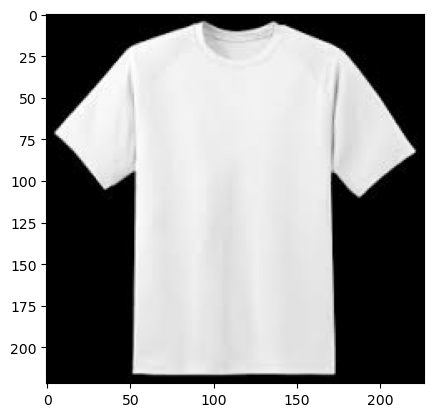

In [14]:
plt.imshow(testing, cmap='grey')

In [15]:
img_resized = cv2.resize(testing, (28, 28), interpolation=cv2.INTER_LINEAR)

In [17]:
img_resized=cv2.bitwise_not(img_resized)

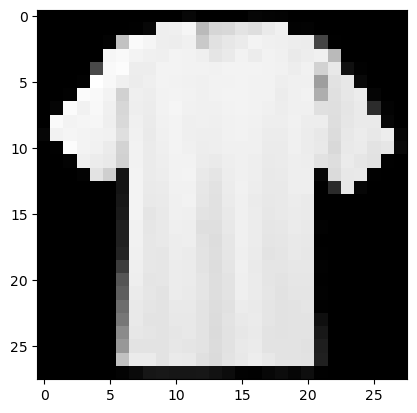

In [18]:
plt.imshow(img_resized, cmap='grey')

In [19]:
Xt = img_resized.reshape(1,28,28,1)
model.predict(Xt)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


array([[2.04061970e-01, 4.30674334e-07, 3.51102171e-05, 6.73821996e-05,
        1.42303795e-08, 2.05508986e-05, 7.95237124e-01, 5.63048583e-04,
        1.41090250e-05, 3.80276191e-07]], dtype=float32)

In [ ]:
print(labels[model.predict(Xt).argmax()])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
Shirt
